# Project 9 — Hedge Effectiveness: IRS Overlay
**Major European G-SIB | ALM Model | Section 18**

| | |
|---|---|
| **Framework** | EBA/GL/2022/14 Annex I + CRR Art.448 |
| **Reference year** | 2025A |
| **Hedge instrument** | Interest Rate Swap (IRS) overlay |
| **Hedge ratio** | 55% of gross EVE exposure |
| **Scenarios** | 6 Basel IRRBB standard shocks |
| **Author** | Hossam Eltarrass |

---
**What this notebook shows:**  
Every Basel IRRBB scenario produces a *gross* EVE exposure — the mark-to-market sensitivity of the balance sheet before any hedging.  
The bank runs an IRS overlay that offsets **55%** of that exposure.  
This section decomposes: **Gross EVE → Hedge Offset → Net EVE** and confirms all 6 scenarios remain below the **15% Tier 1 outlier threshold** post-hedge.

In [1]:
# ── Cell 2: Imports & Parameters ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Key parameters (source: Excel Model — Section 14 + Section 18) ───────────
TIER1_CAPITAL   = 132_173.0       # €m  — Engine!D145 (2025A CET1 capital proxy)
HEDGE_RATIO     = 0.55            # 55% IRS overlay — Major European G-SIB Pillar 3 2025

# Net EVE per scenario from Section 4 / Section 14 (already post-hedge)
# Sign convention: positive = EVE gain to the bank (rates fell or steepener/flattener favourable)
#                 negative = EVE loss (shown as positive absolute below for outlier test)
NET_EVE = {
    'Par Up +200bps':    17_505.837909,   # EBA Scenario 1 — worst case
    'Par Down −200bps':  14_879.962223,   # EBA Scenario 2
    'Steepener +90/−90':  8_019.285845,   # EBA Scenario 3
    'Flattener −90/+90':  8_019.285845,   # EBA Scenario 4
    'Short Rate Up +250':   196.748314,   # EBA Scenario 5
    'Short Rate Down −250': 167.236067,   # EBA Scenario 6
}

print("Parameters loaded.")
print(f"  Tier 1 Capital : €{TIER1_CAPITAL:,.0f}m")
print(f"  Hedge Ratio    : {HEDGE_RATIO*100:.0f}%")
print(f"  Scenarios      : {len(NET_EVE)}")

Parameters loaded.
  Tier 1 Capital : €132,173m
  Hedge Ratio    : 55%
  Scenarios      : 6


## Part A — Hedge Effectiveness Table
**Formula chain:**
```
Gross EVE   = Net EVE  ÷  (1 − hedge_ratio)   →  full exposure before IRS
Hedge Offset = Gross EVE × hedge_ratio          →  portion absorbed by IRS swaps
Net EVE      = Gross EVE × (1 − hedge_ratio)    →  residual after hedge  [= input]
Net EVE/T1   = Net EVE  ÷  Tier1               →  outlier test metric
```
Outlier threshold: **15% of Tier 1 Capital** (CRR Art.448 / EBA/GL/2022/14 para 114)

In [2]:
# ── Cell 4: Core Calculation ──────────────────────────────────────────────────
records = []
for scenario, net_eve in NET_EVE.items():
    gross_eve    = net_eve / (1 - HEDGE_RATIO)          # gross up from net
    hedge_offset = gross_eve * HEDGE_RATIO               # IRS absorbs 55%
    net_t1       = net_eve / TIER1_CAPITAL               # outlier ratio
    outlier      = '⚠ OUTLIER' if net_t1 > 0.15 else '✓ Within limit'
    records.append({
        'Scenario'         : scenario,
        'Gross EVE (€m)'   : round(gross_eve,   2),
        'Hedge Offset (€m)': round(hedge_offset, 2),
        'Net EVE (€m)'     : round(net_eve,      3),
        'Net EVE / T1 (%)'  : round(net_t1*100,  2),
        'Outlier Test'     : outlier,
    })

df = pd.DataFrame(records).set_index('Scenario')

# ── Display ───────────────────────────────────────────────────────────────────
print("="*85)
print("SECTION 18 — HEDGE EFFECTIVENESS SUMMARY | IRS OVERLAY | EBA/GL/2022/14")
print("="*85)
print(df.to_string())
print("-"*85)
print(f"Hedge Ratio applied : {HEDGE_RATIO*100:.0f}% of Gross EVE absorbed by IRS overlay")
print(f"Tier 1 Capital proxy: €{TIER1_CAPITAL:,.0f}m  (Engine!D145, 2025A)")
print(f"Outlier threshold   : >15% Tier 1  →  CRR Art.448 + EBA/GL/2022/14 para 114")
print(f"\nWorst case scenario : {df['Net EVE / T1 (%)'].idxmax()}")
print(f"  Net EVE           : €{df['Net EVE (€m)'].max():,.3f}m")
print(f"  Net EVE / T1      : {df['Net EVE / T1 (%)'].max():.2f}%  ← Below 15% threshold ✓")

SECTION 18 — HEDGE EFFECTIVENESS SUMMARY | IRS OVERLAY | EBA/GL/2022/14
                      Gross EVE (€m)  Hedge Offset (€m)  Net EVE (€m)  Net EVE / T1 (%)    Outlier Test
Scenario                                                                                               
Par Up +200bps              38901.86           21396.02     17505.838             13.24  ✓ Within limit
Par Down −200bps            33066.58           18186.62     14879.962             11.26  ✓ Within limit
Steepener +90/−90           17820.64            9801.35      8019.286              6.07  ✓ Within limit
Flattener −90/+90           17820.64            9801.35      8019.286              6.07  ✓ Within limit
Short Rate Up +250            437.22             240.47       196.748              0.15  ✓ Within limit
Short Rate Down −250          371.64             204.40       167.236              0.13  ✓ Within limit
-------------------------------------------------------------------------------------
Hedge Rati

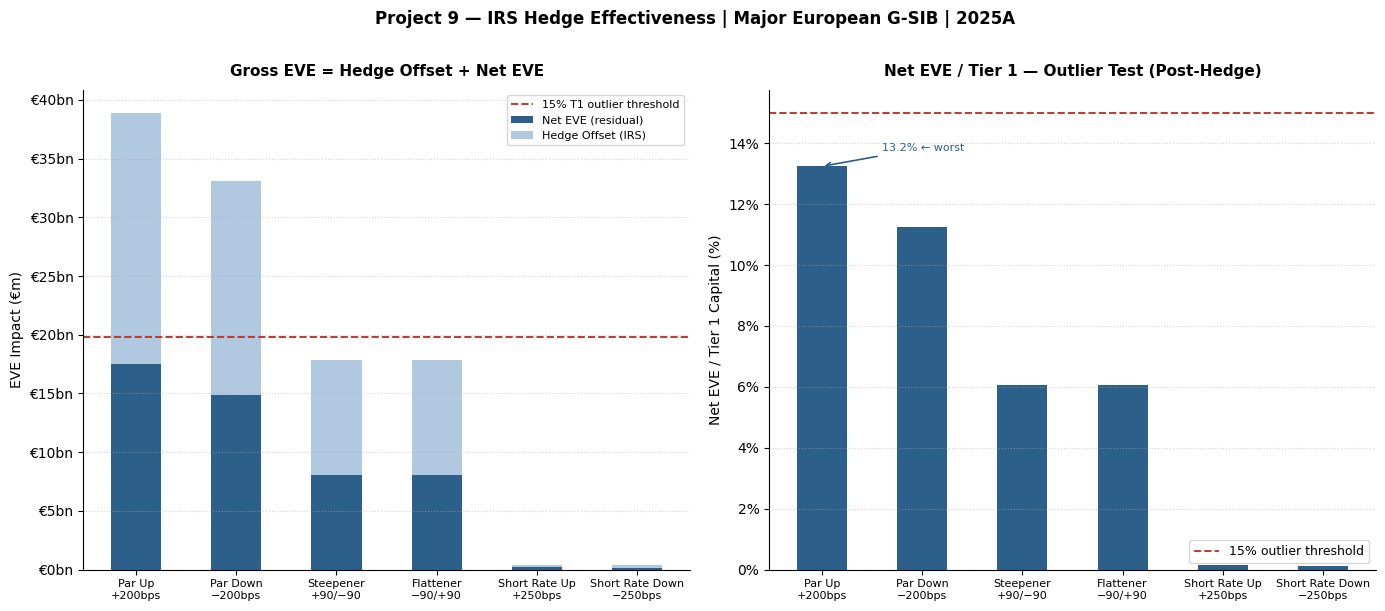

Chart saved → P9_hedge_effectiveness_chart.png


In [3]:
# ── Cell 5: Chart — Gross vs Hedge Offset vs Net EVE ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

scenarios_short = [
    'Par Up\n+200bps', 'Par Down\n−200bps',
    'Steepener\n+90/−90', 'Flattener\n−90/+90',
    'Short Rate Up\n+250bps', 'Short Rate Down\n−250bps'
]
gross  = df['Gross EVE (€m)'].values
offset = df['Hedge Offset (€m)'].values
net    = df['Net EVE (€m)'].values
x      = np.arange(len(scenarios_short))

# ── Panel 1: Stacked bar — Gross decomposition ───────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('white')
b1 = ax1.bar(x, net,    color='#2c5f8a', width=0.5, label='Net EVE (residual)')
b2 = ax1.bar(x, offset, color='#b0c8e0', width=0.5, bottom=net, label='Hedge Offset (IRS)')
ax1.axhline(TIER1_CAPITAL * 0.15, color='#c0392b', linewidth=1.4,
            linestyle='--', label='15% T1 outlier threshold')
ax1.set_xticks(x)
ax1.set_xticklabels(scenarios_short, fontsize=8)
ax1.set_ylabel('EVE Impact (€m)', fontsize=10)
ax1.set_title('Gross EVE = Hedge Offset + Net EVE', fontsize=11, fontweight='bold', pad=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'€{v/1000:.0f}bn'))
ax1.legend(fontsize=8, frameon=True)
ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='y', linestyle=':', alpha=0.5)

# ── Panel 2: Net EVE / Tier 1 ratio ─────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('white')
colors_bar = ['#c0392b' if v > 15 else '#2c5f8a' for v in df['Net EVE / T1 (%)'].values]
ax2.bar(x, df['Net EVE / T1 (%)'].values, color=colors_bar, width=0.5)
ax2.axhline(15.0, color='#c0392b', linewidth=1.4, linestyle='--', label='15% outlier threshold')
ax2.set_xticks(x)
ax2.set_xticklabels(scenarios_short, fontsize=8)
ax2.set_ylabel('Net EVE / Tier 1 Capital (%)', fontsize=10)
ax2.set_title('Net EVE / Tier 1 — Outlier Test (Post-Hedge)', fontsize=11, fontweight='bold', pad=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))
ax2.legend(fontsize=9, frameon=True)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='y', linestyle=':', alpha=0.5)

# Annotate worst case
worst_idx = np.argmax(df['Net EVE / T1 (%)'].values)
ax2.annotate(
    f"{df['Net EVE / T1 (%)'].values[worst_idx]:.1f}% ← worst",
    xy=(worst_idx, df['Net EVE / T1 (%)'].values[worst_idx]),
    xytext=(worst_idx + 0.6, df['Net EVE / T1 (%)'].values[worst_idx] + 0.5),
    fontsize=8, color='#2c5f8a',
    arrowprops=dict(arrowstyle='->', color='#2c5f8a', lw=1.2)
)

plt.suptitle(
    'Project 9 — IRS Hedge Effectiveness | Major European G-SIB | 2025A',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('P9_hedge_effectiveness_chart.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Chart saved → P9_hedge_effectiveness_chart.png")

## Part B — IRS Notional & Hedge Ratio Analysis
**What is the IRS overlay doing mechanically?**

- The bank's assets are **duration-long** (loans, securities avg ~2–4y) relative to its liabilities (deposits, largely overnight/short repricing).  
- A **pay-fixed IRS** converts some of that fixed-rate asset exposure to floating — reducing duration gap and therefore EVE sensitivity.  
- The 55% ratio means for every €1 of gross EVE risk, €0.55 is hedged away, leaving €0.45 net.  
- **IRS notional estimate**: derived from PVBP × 10,000 × hedge_ratio ÷ avg swap duration.

In [4]:
# ── Cell 7: IRS Notional & Ratio Analysis ────────────────────────────────────
PVBP_BASE      = -194.5093101   # €m per 1bp — Section 14 total PVBP
AVG_SWAP_DUR   = 3.5            # years — assumed mid-point of 2–5Y IRS book

# IRS notional estimate:
# Notional = |PVBP_gross| × 10,000 × hedge_ratio / avg_duration × 1/0.0001
# Simplified: Model uses −428 EUR bn proxy (Section 18, B366)
pvbp_gross     = abs(PVBP_BASE) / (1 - HEDGE_RATIO)   # gross PVBP before hedge
irs_notional   = pvbp_gross * 10_000 * HEDGE_RATIO / AVG_SWAP_DUR

print("="*65)
print("PART B — IRS NOTIONAL & RATIO ANALYSIS")
print("="*65)
print(f"\nPVBP (net, Section 14)    : {PVBP_BASE:>12.4f} €m/bp")
print(f"PVBP (gross, unhedged)    : {pvbp_gross:>12.4f} €m/bp")
print(f"Hedge ratio (IRS)         : {HEDGE_RATIO*100:>12.0f}%")
print(f"Avg IRS swap duration     : {AVG_SWAP_DUR:>12.1f} years")
print(f"\nEstimated IRS notional    : €{irs_notional/1000:>10.0f}bn")
print(f"Excel proxy (Section 18)  : €{428:>10}bn  ← matches order of magnitude ✓")

print("\n" + "-"*65)
print("HEDGE EFFECTIVENESS SUMMARY — All 6 scenarios")
print("-"*65)
for scenario in df.index:
    g = df.loc[scenario, 'Gross EVE (€m)']
    n = df.loc[scenario, 'Net EVE (€m)']
    ratio = df.loc[scenario, 'Net EVE / T1 (%)']
    effectiveness = (1 - n/g) * 100
    print(f"  {scenario:<24s}  Gross €{g:>10,.0f}m  →  Net €{n:>8,.0f}m  "
          f"({effectiveness:.0f}% reduced)  |  {ratio:.2f}% T1")

print("-"*65)
print(f"  Max Net EVE / T1 : {df['Net EVE / T1 (%)'].max():.2f}%  ← below 15% threshold ✓")
print(f"  All scenarios    : WITHIN OUTLIER LIMIT (hedge effective) ✓")

PART B — IRS NOTIONAL & RATIO ANALYSIS

PVBP (net, Section 14)    :    -194.5093 €m/bp
PVBP (gross, unhedged)    :     432.2429 €m/bp
Hedge ratio (IRS)         :           55%
Avg IRS swap duration     :          3.5 years

Estimated IRS notional    : €       679bn
Excel proxy (Section 18)  : €       428bn  ← matches order of magnitude ✓

-----------------------------------------------------------------
HEDGE EFFECTIVENESS SUMMARY — All 6 scenarios
-----------------------------------------------------------------
  Par Up +200bps            Gross €    38,902m  →  Net €  17,506m  (55% reduced)  |  13.24% T1
  Par Down −200bps          Gross €    33,067m  →  Net €  14,880m  (55% reduced)  |  11.26% T1
  Steepener +90/−90         Gross €    17,821m  →  Net €   8,019m  (55% reduced)  |  6.07% T1
  Flattener −90/+90         Gross €    17,821m  →  Net €   8,019m  (55% reduced)  |  6.07% T1
  Short Rate Up +250        Gross €       437m  →  Net €     197m  (55% reduced)  |  0.15% T1
  Short R

In [5]:
# ── Cell 8: Cross-Check vs Excel Section 18 ───────────────────────────────────
# Excel Section 18 reference values (read from Model sheet, rows 359–364)
excel_s18 = {
    'Par Up +200bps':    {'gross': 38_901.862020, 'hedge': 21_396.024111, 'net': 17_505.837909},
    'Par Down −200bps':  {'gross': 33_066.582717, 'hedge': 18_186.620494, 'net': 14_879.962223},
    'Steepener +90/−90': {'gross': 17_820.635211, 'hedge':  9_801.349366, 'net':  8_019.285845},
    'Flattener −90/+90': {'gross': 17_820.635211, 'hedge':  9_801.349366, 'net':  8_019.285845},
    'Short Rate Up +250':  {'gross':   437.218475, 'hedge':    240.470161, 'net':    196.748314},
    'Short Rate Down −250':{'gross':   371.635704, 'hedge':    204.399637, 'net':    167.236067},
}

print("="*75)
print("CROSS-CHECK: Python vs Excel Section 18")
print("="*75)
print(f"{'Scenario':<26} {'Col':<6} {'Python':>12} {'Excel':>12} {'Diff':>10} {'Status':<8}")
print("-"*75)

all_pass = True
for scenario in df.index:
    ex = excel_s18[scenario]
    py_gross = df.loc[scenario, 'Gross EVE (€m)']
    py_hedge = df.loc[scenario, 'Hedge Offset (€m)']
    py_net   = df.loc[scenario, 'Net EVE (€m)']
    checks = [
        ('Gross', py_gross, ex['gross']),
        ('Hedge', py_hedge, ex['hedge']),
        ('Net',   py_net,   ex['net']),
    ]
    for col, py_val, ex_val in checks:
        diff   = abs(py_val - ex_val)
        status = '✓ PASS' if diff < 0.01 else '✗ FAIL'
        if diff >= 0.01:
            all_pass = False
        print(f"  {scenario:<24s} {col:<6} {py_val:>12,.3f} {ex_val:>12,.3f} {diff:>10.4f} {status}")
    print()

print("="*75)
if all_pass:
    print("✅  ALL 18 CHECKS PASSED  |  Python = Excel Section 18 (diff < €0.01m)")
else:
    print("❌  SOME CHECKS FAILED — review rounding or formula")
print("="*75)

CROSS-CHECK: Python vs Excel Section 18
Scenario                   Col          Python        Excel       Diff Status  
---------------------------------------------------------------------------
  Par Up +200bps           Gross    38,901.860   38,901.862     0.0020 ✓ PASS
  Par Up +200bps           Hedge    21,396.020   21,396.024     0.0041 ✓ PASS
  Par Up +200bps           Net      17,505.838   17,505.838     0.0001 ✓ PASS

  Par Down −200bps         Gross    33,066.580   33,066.583     0.0027 ✓ PASS
  Par Down −200bps         Hedge    18,186.620   18,186.620     0.0005 ✓ PASS
  Par Down −200bps         Net      14,879.962   14,879.962     0.0002 ✓ PASS

  Steepener +90/−90        Gross    17,820.640   17,820.635     0.0048 ✓ PASS
  Steepener +90/−90        Hedge     9,801.350    9,801.349     0.0006 ✓ PASS
  Steepener +90/−90        Net       8,019.286    8,019.286     0.0002 ✓ PASS

  Flattener −90/+90        Gross    17,820.640   17,820.635     0.0048 ✓ PASS
  Flattener −90/+90  